
# Electron Affinity of Pb : spin-orbit coupling (SOC) in ab initio AFQMC
------------------------------------------------------------------------

At the end of this example, you will know how to include SOC in ab initio AFQMC calculations.

The electron affinity (EA) of heavy elements is strongly affected by SOC.
For $Pb$, the inclusion of SOC changes the EA by about 1 eV [1];
The neutral $Pb$ atom has a $6s^26p^2$ electron configuration with $^3P_0$ experimentally observed ground state
leading to rather large SOC effects.
The $Pb^-$ ion has a spin-quartet $6s^26p^3$ electron configuration with zero orbital angular momentum leading to
much SOC effects than the neutral atom.
Accounting for SOC is, of course, critical to achieve quantitative accuracy.

AFQMC is able to exactly include SOC it is formulated in 2nd quantization for a general orbital
basis - i.e. versus real space methods in which non-local terms in the Hamiltonian such as SOC
must be sampled - making it an ideal tool for the study of systems and observables
where SOC effects are important.

## References
--------------

[1] Brandon Eskridge, Henry Krakauer, Hao Shi, Shiwei Zhang; Ab initio calculations in atoms, molecules, and solids, treating spin–orbit coupling and electron interaction on an equal footing. J. Chem. Phys. 7 January 2022; 156 (1): 014107. https://doi.org/10.1063/5.0075900   
[2] K. A. Peterson, D. Figgen, E. Goll, H. Stoll, and M. Dolg, J. Chem. Phys. 119, 11113 (2003). https://doi.org/10.1063/1.1622924   
[3] K. A. Peterson, B. C. Shepler, D. Figgen, and H. Stoll, J. Phys. Chem. A 110, 13877 (2006). https://doi.org/10.1021/jp065887l    
[4] B. Metz, H. Stoll, and M. Dolg, J. Chem. Phys. 113, 2563 (2000). https://doi.org/10.1063/1.1305880    
[5] K. A. Peterson, J. Chem. Phys. 119, 11099 (2003). https://doi.org/10.1063/1.1622923    

# Set Up Input for SAFIRE
-------------------------

We we will use the relativistic Stuttgart effective core potentials (ECPs), in order to
capture both spin-orbit coupling (SOC) and scalar relativistic effects, as
well as the corresponding augmented cGTO basis sets [2-5].

## ▶️ Run the code block below to load the ECP and basis definitions
--------------------------------------------------------------------

In [1]:
%load_ext autoreload
# setup the tutorials by runnig this block
from pathlib import Path
from tutorial_utils import run_afqmc, get_scratch_dir

# For you TODO: set a scratch directory for the files that will be generated
home = Path.home()
scratch_dir = get_scratch_dir("03_ex_ea_of_Pb", home / ".scratch")

ecp_soc = {
    'Pb' : '''
    Pb nelec 60
    Pb ul
    2       1.0000000              0.0000000
    Pb S
    2      12.2963030            281.2854990
    2       8.6326340             62.5202170
    Pb P
    2      10.2417900             72.2768970      -144.553795
    2       8.9241760            144.5910830       144.591083
    2       6.5813420              4.7586930        -9.517385
    2       6.2554030              9.9406210         9.940621
    Pb D
    2       7.7543360             35.8485070       -35.848507
    2       7.7202810             53.7243420        35.816228
    2       4.9702640             10.1152560       -10.115256
    2       4.5637890             14.8337310         9.889154
    Pb F
    2       3.8875120             12.2098920        -8.139928
    2       3.8119630             16.1902910         8.095145
    Pb G
    2       5.6915770             -9.0966650         4.548332
    2       5.7155670            -11.5319960        -4.612798
    '''
}

aug_cc_pvdz_pp = r"""
BASIS "ao basis" SPHERICAL PRINT
#BASIS SET: (9s,7p,7d) -> [5s,4p,3d]
Pb    S
     37.4583000              0.0248240              0.0000000              0.0067850              0.0000000
     23.3170000             -0.1810620              0.0000000             -0.0601870              0.0000000
     14.5759000              0.5007060              0.0000000              0.1889710              0.0000000
      6.4337600             -0.9797370              0.0000000             -0.4248380              0.0000000
      1.6671900              0.9666300              0.0000000              0.6220350              0.0000000
      0.8077320              0.4364870              0.0000000              0.3160880              0.0000000
      0.2270840              0.0136860              1.0000000             -0.7594740              0.0000000
      0.0842520             -0.0020210              0.0000000             -0.5151310              1.0000000
Pb    S
      0.0278000              1.0000000
Pb    P
     10.6186000              0.1701740             -0.0479540              0.0000000
      7.1878100             -0.4241790              0.1245560              0.0000000
      1.8943900              0.6934430             -0.2597760              0.0000000
      0.8167090              0.4737730             -0.1414800              0.0000000
      0.2036880              0.0290470              0.5317690              0.0000000
      0.0649730             -0.0043860              0.6087590              1.0000000
Pb    P
      0.0197000              1.0000000
Pb    D
     13.7266000              0.0107870              0.0000000
      6.9898300             -0.0666500              0.0000000
      2.1735200              0.3342590              0.0000000
      1.0281200              0.4826840              0.0000000
      0.4558570              0.3004140              0.0000000
      0.1822000              0.0632580              1.0000000
Pb    D
      0.0609000              1.0000000
END
"""

# Generate inputs for the Neutral atom
---------------------------------------

We will begin by generating the Hamiltonian and trial wavefunction for the neutral Pb atom.

## ▶️ Run PySCF for the neutral atom to generate a basis and SOC-GHF trial wavefunction
----------------------------------------------------------------------------------------

In [2]:
from pyscf import gto, scf

neutral_scratch_dir = scratch_dir / "neutral_atom"
neutral_scratch_dir.mkdir(exist_ok=True, parents=True)

## Run SOC-GHF using PySCF
mol = gto.M(
    atom="Pb 0. 0. 0.",
    basis=aug_cc_pvdz_pp,
    ecp=ecp_soc,
    charge=0,
    spin=2,
    verbose=4
)

# 1. Compute ROHF orbitals to use as a basis. NOTE: SOC will be ignored!
mf = scf.ROHF(mol)
mf.chkfile = neutral_scratch_dir/'rohf.chk'
mf.kernel()

# perform stability analysis - see PySCF example:
# https://github.com/pyscf/pyscf.github.io/blob/master/examples/scf/17-stability.py
mo1 = mf.stability()[0]
dm1 = mf.make_rdm1(mo1, mf.mo_occ)
mf = mf.run(dm1)
mf.stability()
mf.kernel()

print(f"ROHF electronic energy: {mf.energy_elec()}")

# 2.a. compute a "No SOC" trial wavefunction
mf = scf.GHF(mol=mol)
mf.chkfile = neutral_scratch_dir/'ghf.chk'
mf.kernel()

mo1 = mf.stability()
dm1 = mf.make_rdm1(mo1, mf.mo_occ)
mf = mf.run(dm1)
mf.stability()
mf.kernel()

print(f"GHF electronic energy: {mf.energy_elec()}")

# 2.b. compute a "SOC" trial wavefunction
mf = scf.GHF(mol=mol)
mf.chkfile = neutral_scratch_dir/'ghf_soc.chk'
mf.with_soc = True
mf.kernel()

mo1 = mf.stability()
dm1 = mf.make_rdm1(mo1, mf.mo_occ)
mf = mf.run(dm1)
mf.stability()
mf.kernel()

print(f"SOC-GHF electronic energy: {mf.energy_elec()}")

System: uname_result(system='Linux', node='worker6100', release='6.1.134.1.fi', version='#1 SMP Thu Apr 24 11:49:26 EDT 2025', machine='x86_64')  Threads 64
Python 3.13.2 (main, Jun 10 2025, 19:12:13) [GCC 13.3.0]
numpy 2.3.5  scipy 1.17.0  h5py 3.15.1
Date: Tue Feb  3 13:43:37 2026
PySCF version 2.12.0
PySCF path  /mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 1
[INPUT] num. electrons = 22
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 2
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 Pb     0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0

nuclear repulsion = 0


number of shells = 6


number of NR pGTOs = 65


number of NR cGTOs = 32


basis = 
BASIS "ao basis" SPHERICAL PRINT
#BASIS SET: (9s,7p,7d) -> [5s,4p,3d]
Pb    S
     37.4583000              0.0248240              0.0000000              0.0067850              0.0000000
     23.3170000             -0.1810620              0.0000000             -0.0601870              0.0000000
     14.5759000              0.5007060              0.0000000              0.1889710              0.0000000
      6.4337600             -0.9797370              0.0000000             -0.4248380              0.0000000
      1.6671900              0.9666300              0.0000000              0.6220350              0.0000000
      0.8077320              0.4364870              0.0000000              0.3160880              0.0000000
      0.2270840              0.0136860              1.0000000             -0.7594740              0.0000000
      0.0842520             -0.0020210              0.0000000             -0.5151310              1.0000000
Pb    S
      0.0278000              1.0000000
Pb

...

cycle= 1 E= -191.898242050352  delta_E= -5.68e-14  |g|= 5.6e-08  |ddm|= 7.21e-07


  HOMO = -0.25457497448917  LUMO = 0.00280535793109637


Extra cycle  E= -191.898242050352  delta_E= -1.14e-13  |g|= 4.4e-08  |ddm|= 4.33e-07


converged SCF energy = -191.898242050352  <S^2> = 1.6892515  2S+1 = 2.7851402


SOC-GHF electronic energy: (np.float64(-191.8982420503524), np.float64(144.31697455192096))


## ▶️ Generate and Write Hamiltonian and Trial wavefunction for Neutral Atom
-----------------------------------------------------------------------------

We generate the Hamiltonian and trial wavefunction in the usual way
with the exception that `write_hamil_mol()` must be explicitly
told to write the spin-orbit coupling integrals via the `with_soc=True`
keyword argument.

For the initial wavefunction, we use the ground state of the non-interacting Hamiltonian
as this was founds in [1] to lead to siginificantly faster equilibration than using
the SOC-GHF or ROHF solution for the initial wavefunction.

In [3]:
%autoreload
import h5py as h5
import numpy as np

from afqmctools.utils.pyscf_utils import load_from_pyscf_chk_mol
from afqmctools.hamiltonian.mol import write_hamil_mol
from afqmctools.wavefunction.mol import write_wfn_mol

# inputs
local_scratch_dir = neutral_scratch_dir
basis_chk = local_scratch_dir / 'rohf.chk'
ghf_chkfile = local_scratch_dir / 'ghf.chk'
ghf_soc_chkfile = local_scratch_dir / 'ghf_soc.chk'
chol_tol = 1e-5

# output
fout = local_scratch_dir / 'afqmc_sf.h5'
fout_soc = local_scratch_dir / 'afqmc_soc.h5'

#####################################
#                                   #
#  Write Hamiltonian in ROHF basis  #
#                                   #
#####################################

# Save the Hamiltonian
basis_scf_data = load_from_pyscf_chk_mol(
    chkfile = basis_chk,
)

# for SOC, we need to request that SOC integrals be included.
write_hamil_mol(
    basis_scf_data,
    fout_soc,
    chol_tol,
    dense=True,
    real_chol=True,
    verbose=True,
    walker_type='ghf',
    with_soc=True
)

#####################################
#                                   #
#    Write GHF Wavefunction         #
#                                   #
#####################################

wfn_scf_data = load_from_pyscf_chk_mol(
    chkfile = ghf_soc_chkfile,
)

write_wfn_mol(
    wfn_scf_data,
    fout_soc,
    basis_scf_data=basis_scf_data
)


Building Hamiltonian with SOC
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 32.
 # Performing modified Cholesky decomposition on ERI tensor.
 # Generating Cholesky decomposition of ERIs.
 # max number of cholesky vectors = 320
        iteration      max_residual              time
                0  1.0269698857e+00  2.2090911865e-02
                1  2.3405949268e-01  9.4580650330e-04
                2  2.3405949268e-01  9.5367431641e-04
                3  2.3405949268e-01  9.4246864319e-04
                4  2.0007931903e-01  7.5585842133e-03
                5  9.5783467283e-02  2.3527145386e-03
                6  8.0810042661e-02  1.9235610962e-03
                7  7.3271755851e-02  1.7988681793e-03
                8  7.3271755851e-02  1.7936229706e-03
                9  7.3271755851e-02  1.7709732056e-03
               10  6.9817404107e-02  3.8051605225e-04
               11  6.5251225479e-02  7.4701309204e-03
               12  6.1229879730e-02  3.57675

               49  1.3101732146e-02  7.3657035828e-03
               50  1.2111916545e-02  7.5862407684e-03
               51  1.2111916545e-02  7.5705051422e-03
               52  1.1656569172e-02  1.6260147095e-03
               53  1.1426809755e-02  3.3071041107e-03
               54  1.1426809755e-02  3.2892227173e-03
               55  1.0818605460e-02  3.8790702820e-04
               56  1.0529946270e-02  3.8790702820e-04
               57  1.0526596295e-02  2.3555755615e-04
               58  1.0460923168e-02  2.1004676819e-04
               59  1.0460923168e-02  2.0766258240e-04
               60  9.4414864918e-03  3.8337707520e-04
               61  9.3199172174e-03  7.4722766876e-03
               62  8.2713519915e-03  7.4942111969e-03
               63  8.1290525530e-03  7.4131488800e-03
               64  8.1290525530e-03  7.5533390045e-03
               65  7.9175893530e-03  1.2571811676e-03
               66  7.5096454595e-03  3.2997131348e-03
               67  6.5305710

              104  7.8474330722e-04  7.9898834229e-03
              105  6.4366709894e-04  1.1058568954e-02
              106  6.4366709894e-04  8.1653594971e-03
              107  6.2066725482e-04  1.0006427765e-03
              108  5.9516884411e-04  3.3507347107e-03
              109  5.8204230360e-04  3.3288002014e-03
              110  5.8204230360e-04  3.3280849457e-03
              111  5.5441608442e-04  7.2932243347e-04
              112  5.5441608442e-04  7.2836875916e-04
              113  5.1080449857e-04  1.8029212952e-03
              114  5.1080449857e-04  1.8072128296e-03
              115  4.9812799203e-04  7.4326992035e-03
              116  3.4403744346e-04  7.9064369202e-03
              117  3.3959369516e-04  7.6389312744e-03
              118  3.3401036275e-04  7.7710151672e-03
              119  3.3140443465e-04  8.0277919769e-03
              120  2.9372858557e-04  7.4958801270e-04
              121  2.8470155971e-04  7.2319507599e-03
              122  2.8470155

Walker type is GHF/noncollinear; using RHF-like initial wavefunction for a pure spin state. See J. Chem. Phys. 128, 114309 (2008) DOI: /10.1063/1.2838983


(12, 10)

## ▶️ Run SAFIRE
----------------

Running AFQMC locally with 16 mpi tasks


--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on worker6100 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 37f8dfbd4713f6c1dc37eb0880f08ed3a64a8a53-dirty
app git commit date: Mon Jan 26 13:59:12 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 16 
    -- MPI nodes      : 1 
    -- MPI tasks      : 16 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: afqmc_soc.h5
walker_set: 
  walker_type: NONCOLLINEAR
hdf_read_file: 
set_nwalker_to_target: false
n_walkers_per_mpi_task: 100
timestep: 0.0050000000000000001
seed: 42
initial_Es


NOMSD input:
nbatch: 0
number_of_references: -1
rediag: false



****************************************************
               Initializing Propagator 

****************************************************

BasePropagator input:

nbatch: 0
nbatch_qr: 0
i: -1
a: -1
vbias_bound: 50
external_field_scale: 1
upper_cutoff_scale: 10
lower_cutoff_scale: 1
apply_constrain: true
importance_sampling: true
substractMF: true
hybrid: true
printP1eigval: false
free_projection: false
denseP1: false
external_field: 
excited: 
debug_verbosity: false




 --------------- Constructing Propagator ------------------ 

 Using sequential propagation. 
 vbias_bound: 50
 Using sparse 1-body propagator
 Using hybrid method to calculate the weights during the propagation.


 Local Energy of starting determinant 
  - Total energy    : (-191.883864, 0.004659)
  - One-body energy : (-335.908432, 0.030334)
  - Coulomb energy  : (159.048587, -0.026276)
  - Exchange energy : (-15.024020, 0.000601)

****************************************************
               Initializing Estimators 

****************************************************

 EstimatorHandler input:
walker_set: 
  walker_type: NONCOLLINEAR
wavefunction: 
  filename: afqmc_soc.h5
timestep: 0.005
steps: 20000
n_walkers_per_mpi_task: 100
measure_interval_multiplier: 1
population_control_interval: 5
walker_ortho_interval: 10
seed: 42


BasicEstimator input:
timers: false
nhist: 0
measure_interval_multiplier: 1
_population_control_interval: 5


  BasicEstimator: Number of products in weight history: 0
EnergyEstimator input:
print_components: false
print_sign: false
truncate: false
equil: 0
skip: 0
measure_interval_multiplier: 1
_population_control_interval: 5



***********************************

********************************************************* 
      Resizing memory buffer to: 127.14691162109375  MBs. 
********************************************************* 



An exception was raised:  Command '['mpirun', '-np', '16', '/mnt/home/beskridge/software/SAFIRE_dev/build/CPU/bin/safire', '--filenames', 'afqmc.json']' timed out after 5999.999964201008 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/03_ex_ea_of_Pb/neutral_atom/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 20              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_co


AFQMC Energy   -191.989302 +/-   0.000954 256.84 20.0/60.5


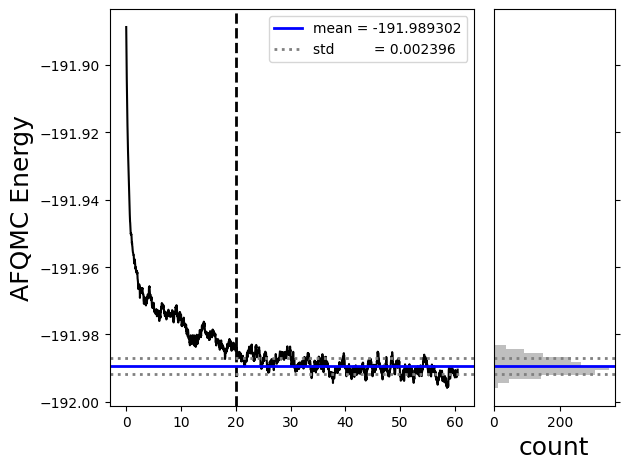

In [4]:
from afqmctools.inputs.from_hdf import write_json
from stats.scalar_dat import analyze_scalar_data

# Write json input file
execute_options = {
    "timestep": 0.005,
    "steps": 20000,
    "measure_interval_multiplier": 1,
    "population_control_interval" : 5,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 100,
    "seed" : 42
}
write_json(
    local_scratch_dir/ "afqmc.json",
    fwfn0=fout_soc,
    exec_opts=execute_options
)

# run AFQMC
run_afqmc(
    run_dir=local_scratch_dir,
    run_mode="local_cpu",
    timeout_mins=100,
    input_file="afqmc.json",
    np=16,             # number of MPI tasks
    output_file=None, #"afqmc.out"   # optionally direct output to file instead of here
)

settings = dict(
    fname = local_scratch_dir/"qmc.s000.scalar.dat",
    xaxis = "time",
    nequil = 20,
    trace = True
)

E,dE = analyze_scalar_data(settings)

# Repeat for Charged $Pb^-$ ion
--------------------------------

## ▶️ Run PySCF
----------------

In [5]:
from pyscf import gto, scf

charged_scratch_dir = scratch_dir / "charged_atoms"
charged_scratch_dir.mkdir(exist_ok=True, parents=True)

## Run SOC-GHF using PySCF
mol = gto.M(
    atom="Pb 0. 0. 0.",
    basis=aug_cc_pvdz_pp,
    ecp=ecp_soc,
    charge=-1,
    spin=3,
    verbose=4
)

# 1. Compute ROHF orbitals to use as a basis.
mf = scf.ROHF(mol)
mf.chkfile = charged_scratch_dir/'rohf.chk'
mf.kernel()

# perform stability analysis - see PySCF example:
# https://github.com/pyscf/pyscf.github.io/blob/master/examples/scf/17-stability.py
mo1 = mf.stability()[0]
dm1 = mf.make_rdm1(mo1, mf.mo_occ)
mf = mf.run(dm1)
mf.stability()
mf.kernel()

print(f"ROHF electronic energy: {mf.energy_elec()}")

# 2.a. compute a "No SOC" trial wavefunction
mf = scf.GHF(mol=mol)
mf.chkfile = charged_scratch_dir/'ghf.chk'
mf.kernel()

mo1 = mf.stability()
dm1 = mf.make_rdm1(mo1, mf.mo_occ)
mf = mf.run(dm1)
mf.stability()
mf.kernel()

print(f"GHF electronic energy: {mf.energy_elec()}")

# 2.b. compute a "SOC" trial wavefunction
mf = scf.GHF(mol=mol)
mf.chkfile = charged_scratch_dir/'ghf_soc.chk'
mf.with_soc = True
mf.kernel()

mo1 = mf.stability()
dm1 = mf.make_rdm1(mo1, mf.mo_occ)
mf = mf.run(dm1)
mf.stability()
mf.kernel()

print(f"SOC-GHF electronic energy: {mf.energy_elec()}")

System: uname_result(system='Linux', node='worker6100', release='6.1.134.1.fi', version='#1 SMP Thu Apr 24 11:49:26 EDT 2025', machine='x86_64')  Threads 64
Python 3.13.2 (main, Jun 10 2025, 19:12:13) [GCC 13.3.0]
numpy 2.3.5  scipy 1.17.0  h5py 3.15.1
Date: Tue Feb  3 15:24:02 2026
PySCF version 2.12.0
PySCF path  /mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 1
[INPUT] num. electrons = 23
[INPUT] charge = -1
[INPUT] spin (= nelec alpha-beta = 2S) = 3
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 Pb     0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0

nuclear repulsion = 0


number of shells = 6


number of NR pGTOs = 65


number of NR cGTOs = 32


basis = 
BASIS "ao basis" SPHERICAL PRINT
#BASIS SET: (9s,7p,7d) -> [5s,4p,3d]
Pb    S
     37.4583000              0.0248240              0.0000000              0.0067850              0.0000000
     23.3170000             -0.1810620              0.0000000             -0.0601870              0.0000000
     14.5759000              0.5007060              0.0000000              0.1889710              0.0000000
      6.4337600             -0.9797370              0.0000000             -0.4248380              0.0000000
      1.6671900              0.9666300              0.0000000              0.6220350              0.0000000
      0.8077320              0.4364870              0.0000000              0.3160880              0.0000000
      0.2270840              0.0136860              1.0000000             -0.7594740              0.0000000
      0.0842520             -0.0020210              0.0000000             -0.5151310              1.0000000
Pb    S
      0.0278000              1.0000000
Pb

...

cycle= 1 E= -191.909999204531  delta_E= -3.69e-13  |g|= 2.18e-07  |ddm|= 2.14e-06


  HOMO = -0.0302571528044423  LUMO = 0.162034882335688


Extra cycle  E= -191.909999204531  delta_E= -3.69e-13  |g|= 1.48e-07  |ddm|= 1.36e-06


converged SCF energy = -191.909999204531  <S^2> = 3.5071751  2S+1 = 3.8766868


SOC-GHF electronic energy: (np.float64(-191.90999920453146), np.float64(148.81025529093773))


## ▶️ Generate and Write Hamiltonian and trial wavefunction
------------------------------------------------------------

In [6]:
%autoreload
### import h5py as h5
import numpy as np

from afqmctools.utils.pyscf_utils import load_from_pyscf_chk_mol
from afqmctools.hamiltonian.mol import write_hamil_mol
from afqmctools.wavefunction.mol import write_wfn_mol


# inputs
local_scratch_dir = charged_scratch_dir
basis_chk = local_scratch_dir / 'rohf.chk'
ghf_chkfile = local_scratch_dir / 'ghf.chk'
ghf_soc_chkfile = local_scratch_dir / 'ghf_soc.chk'
chol_tol = 1e-5

# output
fout = local_scratch_dir / 'afqmc_sf.h5'
fout_soc = local_scratch_dir / 'afqmc_soc.h5'

#####################################
#                                   #
#  Write Hamiltonian in ROHF basis  #
#                                   #
#####################################

# Save the Hamiltonian
basis_scf_data = load_from_pyscf_chk_mol(
    chkfile = basis_chk,
)

# for SOC, we need to request that SOC integrals be included.
write_hamil_mol(
    basis_scf_data,
    fout_soc,
    chol_tol,
    dense=True,
    real_chol=True,
    verbose=True,
    walker_type='ghf',
    with_soc=True
)

#####################################
#                                   #
#    Write GHF Wavefunction         #
#                                   #
#####################################

wfn_scf_data = load_from_pyscf_chk_mol(
    chkfile = ghf_soc_chkfile,
)

write_wfn_mol(
    wfn_scf_data,
    fout_soc,
    basis_scf_data=basis_scf_data
)

Building Hamiltonian with SOC
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 32.
 # Performing modified Cholesky decomposition on ERI tensor.
 # Generating Cholesky decomposition of ERIs.
 # max number of cholesky vectors = 320
        iteration      max_residual              time
                0  1.0269698857e+00  2.0405054092e-02
                1  2.3405949268e-01  9.5677375793e-04
                2  2.3405949268e-01  9.4604492188e-04
                3  2.3405949268e-01  9.3650817871e-04
                4  2.0007931903e-01  7.4555873871e-03
                5  9.5783467283e-02  2.0132064819e-03
                6  8.0810042661e-02  1.9910335541e-03
                7  7.3271755851e-02  1.8029212952e-03
                8  7.3271755851e-02  1.7883777618e-03
                9  7.3271755851e-02  1.7843246460e-03
               10  6.9817404107e-02  3.7240982056e-04
               11  6.5251225479e-02  7.5078010559e-03
               12  6.1229879730e-02  3.70526

               49  1.3101732146e-02  7.6141357422e-03
               50  1.2111916545e-02  7.4937343597e-03
               51  1.2111916545e-02  7.4911117554e-03
               52  1.1656569172e-02  6.8736076355e-04
               53  1.1426809755e-02  3.2899379730e-03
               54  1.1426809755e-02  3.3106803894e-03
               55  1.0818605460e-02  3.8337707520e-04
               56  1.0529946270e-02  3.8385391235e-04
               57  1.0526596295e-02  2.1171569824e-04
               58  1.0460923168e-02  2.1004676819e-04
               59  1.0460923168e-02  2.1123886108e-04
               60  9.4414864918e-03  3.7670135498e-04
               61  9.3199172174e-03  7.4226856232e-03
               62  8.2713519915e-03  7.6017379761e-03
               63  8.1290525530e-03  8.0552101135e-03
               64  8.1290525530e-03  7.8682899475e-03
               65  7.9175893530e-03  1.1062622070e-03
               66  7.5096454595e-03  3.3128261566e-03
               67  6.5305710

              118  3.3401036275e-04  7.7042579651e-03
              119  3.3140443465e-04  7.4496269226e-03
              120  2.9372858557e-04  7.3194503784e-04
              121  2.8470155971e-04  7.2658061981e-03
              122  2.8470155971e-04  7.4348449707e-03
              123  2.4304566635e-04  3.2520294189e-04
              124  2.1180929272e-04  1.4033317566e-03
              125  2.0312340323e-04  1.4426708221e-03
              126  1.9129588074e-04  7.4279308319e-03
              127  1.7243240215e-04  1.4224052429e-03
              128  1.6862667725e-04  7.4920654297e-03
              129  1.6862667725e-04  7.4534416199e-03
              130  1.6813495332e-04  1.4188289642e-03
              131  1.4726687059e-04  1.7373561859e-03
              132  1.1452171272e-04  9.8609924316e-04
              133  1.0083256235e-04  9.7584724426e-04
              134  1.0083256235e-04  9.5105171204e-04
              135  9.8094193691e-05  1.8146038055e-03
              136  9.7379835

(13, 10)

In [7]:
charged_scratch_dir = scratch_dir / "charged_atoms"
local_scratch_dir = charged_scratch_dir
fout_soc = local_scratch_dir / 'afqmc_soc.h5'

## ▶️ Run SAFIRE
-----------------

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on worker6100 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 37f8dfbd4713f6c1dc37eb0880f08ed3a64a8a53-dirty
app git commit date: Mon Jan 26 13:59:12 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 16 
    -- MPI nodes      : 1 
    -- MPI tasks      : 16 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: afqmc_soc.h5
walker_set: 
  walker_type: NONCOLLINEAR
hdf_read_file: 
set_nwalker_to_target: false
n_walkers_per_mpi_task: 100
timestep: 0.0050000000000000001
seed: 42
initial_Es

 Local Energy of starting determinant 
  - Total energy    : (-191.910289, 0.000000)
  - One-body energy : (-340.709944, 0.000000)
  - Coulomb energy  : (163.967179, 0.000000)
  - Exchange energy : (-15.167524, 0.000000)

****************************************************
               Initializing Estimators 

****************************************************

 EstimatorHandler input:
walker_set: 
  walker_type: NONCOLLINEAR
wavefunction: 
  filename: afqmc_soc.h5
timestep: 0.005
steps: 20000
n_walkers_per_mpi_task: 100
measure_interval_multiplier: 1
population_control_interval: 5
walker_ortho_interval: 10
seed: 42


BasicEstimator input:
timers: false
nhist: 0
measure_interval_multiplier: 1
_population_control_interval: 5


  BasicEstimator: Number of products in weight history: 0
EnergyEstimator input:
print_components: false
print_sign: false
truncate: false
equil: 0
skip: 0
measure_interval_multiplier: 1
_population_control_interval: 5



************************************

********************************************************* 
      Resizing memory buffer to: 138.74053955078125  MBs. 
********************************************************* 



An exception was raised:  Command '['mpirun', '-np', '16', '/mnt/home/beskridge/software/SAFIRE_dev/build/CPU/bin/safire', '--filenames', 'afqmc.json']' timed out after 5999.999969496974 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/03_ex_ea_of_Pb/charged_atoms/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 20              
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_c

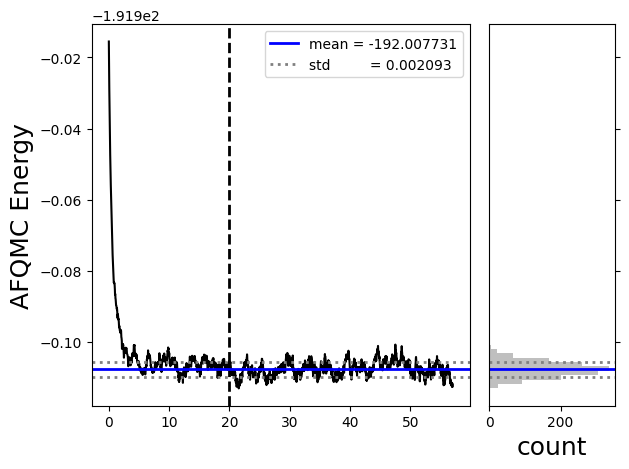

In [8]:
### from afqmctools.inputs.from_hdf import write_json
from stats.scalar_dat import analyze_scalar_data

# Write json input file
execute_options = {
    "timestep": 0.005,
    "steps": 20000,
    "measure_interval_multiplier": 1,
    "population_control_interval" : 5,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 100,
    "seed" : 42
}
write_json(
    local_scratch_dir/ "afqmc.json",
    fwfn0=fout_soc,
    exec_opts=execute_options
)

# run AFQMC
run_afqmc(
    run_dir=local_scratch_dir,
    run_mode="local_cpu",
    timeout_mins=100,
    input_file="afqmc.json",
    np=16,             # number of MPI tasks
    output_file=None, #"afqmc.out"   # optionally direct output to file instead of here
)

settings = dict(
    fname = local_scratch_dir/"qmc.s000.scalar.dat",
    xaxis = "time",
    nequil = 20,
    trace = True
)

E_charged,dE_charged = analyze_scalar_data(settings)

# ✅ Compute the Final Result
------------------------------

Run the codeblock below to get the final result.
It should be 0.48(3) eV for the aug-cc-pVDZ basis set.

In [9]:
import numpy as np

eV = 27.211407953

E = -191.990093
dE = 0.000986

EA = E - E_charged
dEA = np.sqrt( np.power(dE,2) + np.power(dE_charged,2))

print(f"The electron affinity is {EA*eV} +/- {dEA*eV} eV")

The electron affinity is 0.4799674550652258 +/- 0.028373640621307834 eV


You should reproduce the result above if you ran with the same parameters and settings as we did.
Specifically ensure that the seed and number of MPI processes is the same.